In [148]:
import pandas as pd

In [149]:
Original=pd.read_excel("../Data/BUS/Bus_FE.xlsx",engine="openpyxl")


In [150]:
back=Original.copy()

In [151]:
back.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'ROUTE_ID', 'ROUTE_SEQ', 'ON_SEQ',
       'OFF_SEQ', 'PRICE', 'ROUTE_NAMES', 'COMPANY_CODE', 'SERVICE_MODE',
       'SPECIAL_TYPE', 'STOP_NAMES_x', 'ON_SEQ_STOP_ID', 'STOP_NAMES_y',
       'OFF_SEQ_STOP_ID', 'ON_STOP_X', 'ON_STOP_Y', 'OFF_STOP_X', 'OFF_STOP_Y',
       'ON_DISTRICT', 'OFF_DISTRICT', 'DISTANCE', 'COST_INDEX', 'JOURNEY_TIME',
       '區議會分區', 'MEAN_COST_INDEX', 'Income(Median)', 'Area', 'Population',
       'Male Population', 'Female Population', 'Gender Ratio',
       'Population Density', 'Num_Bus_Stop', 'Bus Stop Density', '區議會分區（中文名稱)',
       '按性別劃分的每月主要職業收入（港元）中位數（不包括無酬家庭從業員）.2', '按房屋類型劃分的有人居住的屋宇單位數目.3',
       '按房屋類型劃分的家庭住戶數目.3', '家庭住戶每月按揭供款及借貸還款與收入比率中位數',
       '按上課地點劃分的於香港院校就讀全日制課程的人口.2', '按廳房數目﹝不包括廚房及廁所﹞劃分的家庭住戶數目.2', '家庭住戶平均人數',
       '按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2', '按房屋類型劃分的人口.3',
       '按行業(9)劃分的工作人口.3', '按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目', '按行業(9)劃分的工作人口.5',
       '按工作地點劃分的工作人口.2', '按每月主要職業收入（港元）劃分的工作人口（不包括無酬家

In [152]:
Original.head()

,Unnamed: 0.1,Unnamed: 0,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,ROUTE_NAMES,COMPANY_CODE,SERVICE_MODE,...,按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2,按房屋類型劃分的人口.3,按行業(9)劃分的工作人口.3,按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目,按行業(9)劃分的工作人口.5,按工作地點劃分的工作人口.2,按每月主要職業收入（港元）劃分的工作人口（不包括無酬家庭從業員）.4,按每月主要職業收入（港元）劃分的工作人口（不包括外籍家庭傭工及無酬家庭從業員）.4,按住戶人數劃分的家庭住戶數目,按住戶結構劃分的家庭住戶數目.6
0,0,271,1001,1,17,25,5.8,1,KMB,R,...,1386,9562,8813,2672,5707,23661,14637,14637,37041,37041
1,1,152,1001,1,8,14,6.7,1,KMB,R,...,1051,4721,11877,12214,8010,53720,17962,17962,32089,32089
2,2,254,1001,1,15,25,6.7,1,KMB,R,...,1386,9562,8813,2672,5707,23661,14637,14637,37041,37041
3,3,5,1001,1,1,7,6.7,1,KMB,R,...,1663,3591,16226,26350,7533,62624,15576,15576,29032,29032
4,4,525,1001,2,13,17,6.3,1,KMB,R,...,1051,4721,11877,12214,8010,53720,17962,17962,32089,32089


In [153]:
# 获取所有唯一的公司代码
unique_companies = set()
for code in Original['COMPANY_CODE']:
    companies = code.split('+')
    unique_companies.update(companies)

# 创建新的列，初始值为 0
for company in unique_companies:
    Original[f'Is_{company}'] = 0

# 填充新的列
for index, row in Original.iterrows():
    companies = row['COMPANY_CODE'].split('+')
    for company in companies:
        Original.at[index, f'Is_{company}'] = 1

# 删除原始的 COMPANY_CODE 列
Original.drop(columns=['COMPANY_CODE'], inplace=True)


In [154]:
back.head()

,Unnamed: 0.1,Unnamed: 0,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,ROUTE_NAMES,COMPANY_CODE,SERVICE_MODE,...,按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2,按房屋類型劃分的人口.3,按行業(9)劃分的工作人口.3,按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目,按行業(9)劃分的工作人口.5,按工作地點劃分的工作人口.2,按每月主要職業收入（港元）劃分的工作人口（不包括無酬家庭從業員）.4,按每月主要職業收入（港元）劃分的工作人口（不包括外籍家庭傭工及無酬家庭從業員）.4,按住戶人數劃分的家庭住戶數目,按住戶結構劃分的家庭住戶數目.6
0,0,271,1001,1,17,25,5.8,1,KMB,R,...,1386,9562,8813,2672,5707,23661,14637,14637,37041,37041
1,1,152,1001,1,8,14,6.7,1,KMB,R,...,1051,4721,11877,12214,8010,53720,17962,17962,32089,32089
2,2,254,1001,1,15,25,6.7,1,KMB,R,...,1386,9562,8813,2672,5707,23661,14637,14637,37041,37041
3,3,5,1001,1,1,7,6.7,1,KMB,R,...,1663,3591,16226,26350,7533,62624,15576,15576,29032,29032
4,4,525,1001,2,13,17,6.3,1,KMB,R,...,1051,4721,11877,12214,8010,53720,17962,17962,32089,32089


In [155]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 假设 Original 是你的 DataFrame
encoder = OneHotEncoder(sparse_output=False, dtype=int)  # sparse_output=False 返回密集矩阵
encoded_data = encoder.fit_transform(Original[['SERVICE_MODE']])  # 注意：输入是二维数组

# 将编码结果转换为 DataFrame
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['SERVICE_MODE']))

# 将编码后的 DataFrame 合并回原始 DataFrame
Original = pd.concat([Original, encoded_df], axis=1)

# 删除原始的 SERVICE_MODE 列（可选）
Original.drop('SERVICE_MODE', axis=1, inplace=True)

Original.head()

,Unnamed: 0.1,Unnamed: 0,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,ROUTE_NAMES,SPECIAL_TYPE,STOP_NAMES_x,...,Is_LWB,Is_CTB,Is_PI,Is_KMB,Is_DB,Is_NLB,SERVICE_MODE_N,SERVICE_MODE_NT,SERVICE_MODE_R,SERVICE_MODE_T
0,0,271,1001,1,17,25,5.8,1,0,旺角奶路臣街,...,0,0,0,1,0,0,0,0,1,0
1,1,152,1001,1,8,14,6.7,1,0,九龙寨城公园,...,0,0,0,1,0,0,0,0,1,0
2,2,254,1001,1,15,25,6.7,1,0,协和小学,...,0,0,0,1,0,0,0,0,1,0
3,3,5,1001,1,1,7,6.7,1,0,竹园邨总站,...,0,0,0,1,0,0,0,0,1,0
4,4,525,1001,2,13,17,6.3,1,0,明爱太子宿舍,...,0,0,0,1,0,0,0,0,1,0


In [156]:
back.head()

,Unnamed: 0.1,Unnamed: 0,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,ROUTE_NAMES,COMPANY_CODE,SERVICE_MODE,...,按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2,按房屋類型劃分的人口.3,按行業(9)劃分的工作人口.3,按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目,按行業(9)劃分的工作人口.5,按工作地點劃分的工作人口.2,按每月主要職業收入（港元）劃分的工作人口（不包括無酬家庭從業員）.4,按每月主要職業收入（港元）劃分的工作人口（不包括外籍家庭傭工及無酬家庭從業員）.4,按住戶人數劃分的家庭住戶數目,按住戶結構劃分的家庭住戶數目.6
0,0,271,1001,1,17,25,5.8,1,KMB,R,...,1386,9562,8813,2672,5707,23661,14637,14637,37041,37041
1,1,152,1001,1,8,14,6.7,1,KMB,R,...,1051,4721,11877,12214,8010,53720,17962,17962,32089,32089
2,2,254,1001,1,15,25,6.7,1,KMB,R,...,1386,9562,8813,2672,5707,23661,14637,14637,37041,37041
3,3,5,1001,1,1,7,6.7,1,KMB,R,...,1663,3591,16226,26350,7533,62624,15576,15576,29032,29032
4,4,525,1001,2,13,17,6.3,1,KMB,R,...,1051,4721,11877,12214,8010,53720,17962,17962,32089,32089


In [157]:
Original.shape

(4513, 62)

In [158]:
# from sklearn.preprocessing import LabelEncoder

# # 1. 计算数据的长度
# Original['ON_STOP_NAME_LENGTH'] = Original['STOP_NAMES_x'].apply(len)

# # 2. 使用 LabelEncoder 转换为数字类型的数据
# label_encoder = LabelEncoder()
# Original['ON_STOP_NAME_ENCODED'] = label_encoder.fit_transform(Original['STOP_NAMES_x'])


# # 1. 计算数据的长度
# Original['OFF_STOP_NAME_LENGTH'] = Original['STOP_NAMES_y'].apply(len)

# # 2. 使用 LabelEncoder 转换为数字类型的数据
# label_encoder = LabelEncoder()
# Original['OFF_STOP_NAME_ENCODED'] = label_encoder.fit_transform(Original['STOP_NAMES_y'])


# label_encoder = LabelEncoder()

# Original['DISTRICT_NAME_ENCODED'] = label_encoder.fit_transform(Original['ON_DISTRICT'])


In [159]:
back.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'ROUTE_ID', 'ROUTE_SEQ', 'ON_SEQ',
       'OFF_SEQ', 'PRICE', 'ROUTE_NAMES', 'COMPANY_CODE', 'SERVICE_MODE',
       'SPECIAL_TYPE', 'STOP_NAMES_x', 'ON_SEQ_STOP_ID', 'STOP_NAMES_y',
       'OFF_SEQ_STOP_ID', 'ON_STOP_X', 'ON_STOP_Y', 'OFF_STOP_X', 'OFF_STOP_Y',
       'ON_DISTRICT', 'OFF_DISTRICT', 'DISTANCE', 'COST_INDEX', 'JOURNEY_TIME',
       '區議會分區', 'MEAN_COST_INDEX', 'Income(Median)', 'Area', 'Population',
       'Male Population', 'Female Population', 'Gender Ratio',
       'Population Density', 'Num_Bus_Stop', 'Bus Stop Density', '區議會分區（中文名稱)',
       '按性別劃分的每月主要職業收入（港元）中位數（不包括無酬家庭從業員）.2', '按房屋類型劃分的有人居住的屋宇單位數目.3',
       '按房屋類型劃分的家庭住戶數目.3', '家庭住戶每月按揭供款及借貸還款與收入比率中位數',
       '按上課地點劃分的於香港院校就讀全日制課程的人口.2', '按廳房數目﹝不包括廚房及廁所﹞劃分的家庭住戶數目.2', '家庭住戶平均人數',
       '按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2', '按房屋類型劃分的人口.3',
       '按行業(9)劃分的工作人口.3', '按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目', '按行業(9)劃分的工作人口.5',
       '按工作地點劃分的工作人口.2', '按每月主要職業收入（港元）劃分的工作人口（不包括無酬家

e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


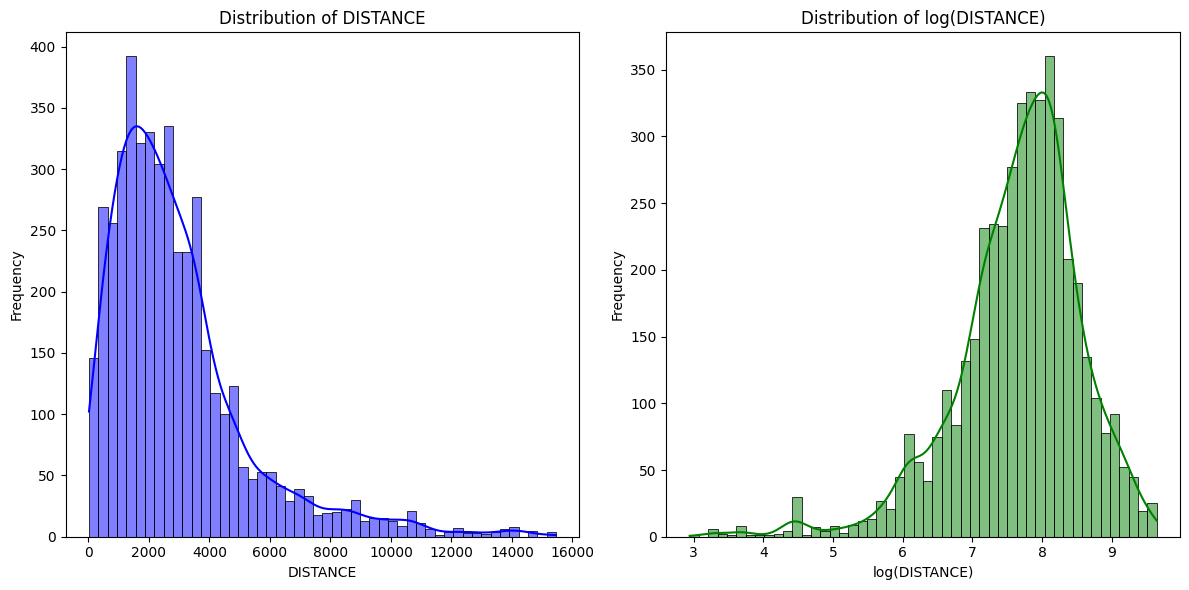

In [160]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# 计算 log(DISTANCE)
Original['LOG_DISTANCE'] = np.log(Original['DISTANCE'])

# 设置画布和子图
plt.figure(figsize=(12, 6))

# 子图 1: DISTANCE 的分布
plt.subplot(1, 2, 1)
sns.histplot(Original['DISTANCE'], kde=True, color='blue', bins=50)
plt.title('Distribution of DISTANCE')
plt.xlabel('DISTANCE')
plt.ylabel('Frequency')

# 子图 2: log(DISTANCE) 的分布
plt.subplot(1, 2, 2)
sns.histplot(Original['LOG_DISTANCE'], kde=True, color='green', bins=50)
plt.title('Distribution of log(DISTANCE)')
plt.xlabel('log(DISTANCE)')
plt.ylabel('Frequency')

# 显示图形
plt.tight_layout()
plt.show()

In [161]:
Original.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'ROUTE_ID', 'ROUTE_SEQ', 'ON_SEQ',
       'OFF_SEQ', 'PRICE', 'ROUTE_NAMES', 'SPECIAL_TYPE', 'STOP_NAMES_x',
       'ON_SEQ_STOP_ID', 'STOP_NAMES_y', 'OFF_SEQ_STOP_ID', 'ON_STOP_X',
       'ON_STOP_Y', 'OFF_STOP_X', 'OFF_STOP_Y', 'ON_DISTRICT', 'OFF_DISTRICT',
       'DISTANCE', 'COST_INDEX', 'JOURNEY_TIME', '區議會分區', 'MEAN_COST_INDEX',
       'Income(Median)', 'Area', 'Population', 'Male Population',
       'Female Population', 'Gender Ratio', 'Population Density',
       'Num_Bus_Stop', 'Bus Stop Density', '區議會分區（中文名稱)',
       '按性別劃分的每月主要職業收入（港元）中位數（不包括無酬家庭從業員）.2', '按房屋類型劃分的有人居住的屋宇單位數目.3',
       '按房屋類型劃分的家庭住戶數目.3', '家庭住戶每月按揭供款及借貸還款與收入比率中位數',
       '按上課地點劃分的於香港院校就讀全日制課程的人口.2', '按廳房數目﹝不包括廚房及廁所﹞劃分的家庭住戶數目.2', '家庭住戶平均人數',
       '按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2', '按房屋類型劃分的人口.3',
       '按行業(9)劃分的工作人口.3', '按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目', '按行業(9)劃分的工作人口.5',
       '按工作地點劃分的工作人口.2', '按每月主要職業收入（港元）劃分的工作人口（不包括無酬家庭從業員）.4',
       '按每月主要職業收入（港元）劃

In [162]:
columns_to_add = back.columns.difference(Original.columns)

# 将这些列拼接到 Original 中
Original = pd.concat([Original, back[columns_to_add]], axis=1)

In [163]:
columns_to_add

Index(['COMPANY_CODE', 'SERVICE_MODE'], dtype='object')

In [164]:
Original.head()

,Unnamed: 0.1,Unnamed: 0,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,ROUTE_NAMES,SPECIAL_TYPE,STOP_NAMES_x,...,Is_KMB,Is_DB,Is_NLB,SERVICE_MODE_N,SERVICE_MODE_NT,SERVICE_MODE_R,SERVICE_MODE_T,LOG_DISTANCE,COMPANY_CODE,SERVICE_MODE
0,0,271,1001,1,17,25,5.8,1,0,旺角奶路臣街,...,1,0,0,0,0,1,0,7.909857,KMB,R
1,1,152,1001,1,8,14,6.7,1,0,九龙寨城公园,...,1,0,0,0,0,1,0,7.703910,KMB,R
2,2,254,1001,1,15,25,6.7,1,0,协和小学,...,1,0,0,0,0,1,0,8.239329,KMB,R
3,3,5,1001,1,1,7,6.7,1,0,竹园邨总站,...,1,0,0,0,0,1,0,7.242082,KMB,R
4,4,525,1001,2,13,17,6.3,1,0,明爱太子宿舍,...,1,0,0,0,0,1,0,7.206377,KMB,R


In [165]:
Original=Original.drop(columns=['ROUTE_NAMES','ON_SEQ','OFF_SEQ','ROUTE_SEQ','ROUTE_ID','ON_SEQ_STOP_ID','OFF_SEQ_STOP_ID','ON_STOP_X','ON_STOP_Y','OFF_STOP_X','OFF_STOP_Y','ON_DISTRICT','OFF_DISTRICT','區議會分區','STOP_NAMES_x','STOP_NAMES_y','Unnamed: 0'],errors='ignore')

In [166]:
Original.head()

,Unnamed: 0.1,PRICE,SPECIAL_TYPE,DISTANCE,COST_INDEX,JOURNEY_TIME,MEAN_COST_INDEX,Income(Median),Area,Population,...,Is_KMB,Is_DB,Is_NLB,SERVICE_MODE_N,SERVICE_MODE_NT,SERVICE_MODE_R,SERVICE_MODE_T,LOG_DISTANCE,COMPANY_CODE,SERVICE_MODE
0,0,5.8,0,2724,0.024715,40,2.169579,18000,6.99,310647,...,1,0,0,0,0,1,0,7.909857,KMB,R
1,1,6.7,0,2217,0.023813,40,3.075867,18000,10.01,410634,...,1,0,0,0,0,1,0,7.703910,KMB,R
2,2,6.7,0,3787,0.039692,40,2.169579,18000,6.99,310647,...,1,0,0,0,0,1,0,8.239329,KMB,R
3,3,6.7,0,1397,0.025438,40,3.179194,16000,9.30,406802,...,1,0,0,0,0,1,0,7.242082,KMB,R
4,4,6.3,0,1348,0.013615,40,3.075867,18000,10.01,410634,...,1,0,0,0,0,1,0,7.206377,KMB,R


In [167]:
Original.head()

,Unnamed: 0.1,PRICE,SPECIAL_TYPE,DISTANCE,COST_INDEX,JOURNEY_TIME,MEAN_COST_INDEX,Income(Median),Area,Population,...,Is_KMB,Is_DB,Is_NLB,SERVICE_MODE_N,SERVICE_MODE_NT,SERVICE_MODE_R,SERVICE_MODE_T,LOG_DISTANCE,COMPANY_CODE,SERVICE_MODE
0,0,5.8,0,2724,0.024715,40,2.169579,18000,6.99,310647,...,1,0,0,0,0,1,0,7.909857,KMB,R
1,1,6.7,0,2217,0.023813,40,3.075867,18000,10.01,410634,...,1,0,0,0,0,1,0,7.703910,KMB,R
2,2,6.7,0,3787,0.039692,40,2.169579,18000,6.99,310647,...,1,0,0,0,0,1,0,8.239329,KMB,R
3,3,6.7,0,1397,0.025438,40,3.179194,16000,9.30,406802,...,1,0,0,0,0,1,0,7.242082,KMB,R
4,4,6.3,0,1348,0.013615,40,3.075867,18000,10.01,410634,...,1,0,0,0,0,1,0,7.206377,KMB,R


In [169]:
Original.to_excel("../Data/BUS/Bus_FE_Processed.xlsx", engine="openpyxl")